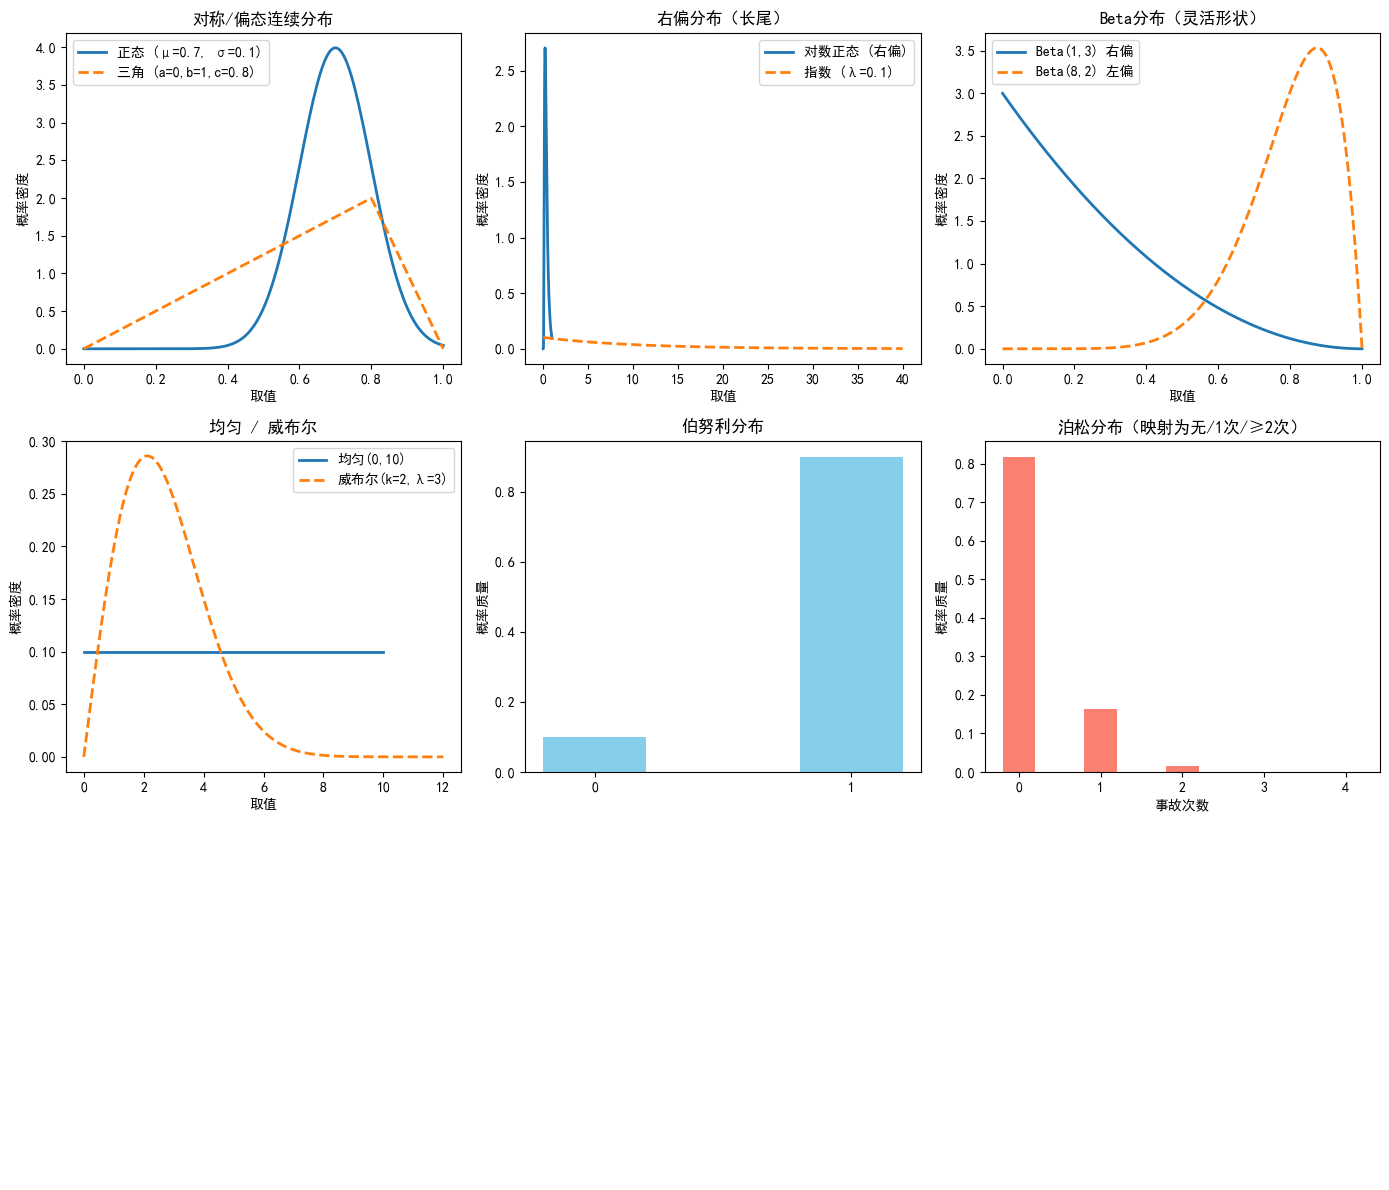

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, expon, uniform, triang, beta, weibull_min, bernoulli, poisson
from scipy.special import logit, expit

# 设置图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False

# 定义常用截断函数（用于显示）
def trunc_pdf(x, dist, a, b):
    """截断分布的概率密度（归一化近似）"""
    pdf = dist.pdf(x)
    cdf_a = dist.cdf(a)
    cdf_b = dist.cdf(b)
    return np.where((x >= a) & (x <= b), pdf / (cdf_b - cdf_a), 0)

# 1. 正态分布（截断于[0,1]）
x_norm = np.linspace(0, 1, 200)
norm_dist = norm(loc=0.7, scale=0.1)
y_norm = trunc_pdf(x_norm, norm_dist, 0, 1)

# 2. 对数正态分布（疲劳作业，截断于[0,1]）
x_lognorm = np.linspace(0, 1, 200)
lognorm_dist = lognorm(s=0.6, scale=np.exp(-1.2))  # 对数均值μ=-1.2，对数标准差σ=0.6
y_lognorm = trunc_pdf(x_lognorm, lognorm_dist, 0, 1)

# 3. 指数分布（经验水平，截断于[0,40]）
x_exp = np.linspace(0, 40, 200)
exp_dist = expon(scale=10)  # λ=0.1 即尺度=10
y_exp = trunc_pdf(x_exp, exp_dist, 0, 40)

# 4. 均匀分布（距离0~10）
x_unif = np.linspace(0, 10, 200)
unif_dist = uniform(0, 10)
y_unif = unif_dist.pdf(x_unif)

# 5. 三角分布（健康程度，a=0,b=1,c=0.8）
x_tri = np.linspace(0, 1, 200)
tri_dist = triang(c=0.8, loc=0, scale=1)  # c = (mode - loc)/scale
y_tri = tri_dist.pdf(x_tri)

# 6. Beta分布（重叠度右偏：α=1,β=3）
x_beta1 = np.linspace(0, 1, 200)
beta_dist1 = beta(a=1, b=3)
y_beta1 = beta_dist1.pdf(x_beta1)

# 7. Beta分布（监测覆盖率左偏：α=8,β=2）
x_beta2 = np.linspace(0, 1, 200)
beta_dist2 = beta(a=8, b=2)
y_beta2 = beta_dist2.pdf(x_beta2)

# 8. 威布尔分布（风速，k=2,λ=3，限于0~12级）
x_weibull = np.linspace(0, 12, 200)
weibull_dist = weibull_min(c=2, scale=3)  # c=形状，scale=尺度
y_weibull = weibull_dist.pdf(x_weibull)

# 9. 伯努利分布（二值）
# 用条形图表示
bernoulli_prob = 0.9
x_bern = [0, 1]
y_bern = [1-bernoulli_prob, bernoulli_prob]

# 10. 泊松分布（事故次数，λ=0.2）
x_pois = np.arange(0, 5)
pois_dist = poisson(mu=0.2)
y_pois = pois_dist.pmf(x_pois)

# 绘图（共5个子图，每个子图含2~3个分布）
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

# 子图1：正态 + 三角
ax = axes[0]
ax.plot(x_norm, y_norm, label='正态 (μ=0.7, σ=0.1)', lw=2)
ax.plot(x_tri, y_tri, '--', label='三角 (a=0,b=1,c=0.8)', lw=2)
ax.set_title('对称/偏态连续分布')
ax.legend()
ax.set_xlabel('取值')
ax.set_ylabel('概率密度')

# 子图2：对数正态 + 指数
ax = axes[1]
ax.plot(x_lognorm, y_lognorm, label='对数正态 (右偏)', lw=2)
ax.plot(x_exp, y_exp, '--', label='指数 (λ=0.1)', lw=2)
ax.set_title('右偏分布（长尾）')
ax.legend()
ax.set_xlabel('取值')
ax.set_ylabel('概率密度')

# 子图3：Beta（右偏+左偏）
ax = axes[2]
ax.plot(x_beta1, y_beta1, label='Beta(1,3) 右偏', lw=2)
ax.plot(x_beta2, y_beta2, '--', label='Beta(8,2) 左偏', lw=2)
ax.set_title('Beta分布（灵活形状）')
ax.legend()
ax.set_xlabel('取值')
ax.set_ylabel('概率密度')

# 子图4：均匀 + 威布尔
ax = axes[3]
ax.plot(x_unif, y_unif, label='均匀(0,10)', lw=2)
ax.plot(x_weibull, y_weibull, '--', label='威布尔(k=2,λ=3)', lw=2)
ax.set_title('均匀 / 威布尔')
ax.legend()
ax.set_xlabel('取值')
ax.set_ylabel('概率密度')

# 子图5：伯努利（条形）
ax = axes[4]
ax.bar(x_bern, y_bern, width=0.4, color='skyblue', label='伯努利(p=0.9)')
ax.set_xticks([0,1])
ax.set_xticklabels(['0', '1'])
ax.set_title('伯努利分布')
ax.set_ylabel('概率质量')

# 子图6：泊松（条形）
ax = axes[5]
ax.bar(x_pois, y_pois, width=0.4, color='salmon', label='泊松(λ=0.2)')
ax.set_xticks(x_pois)
ax.set_xlabel('事故次数')
ax.set_ylabel('概率质量')
ax.set_title('泊松分布（映射为无/1次/≥2次）')

# 隐藏多余子图（共9个，只用了前6个）
for i in range(6, 9):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

c:\Users\69462\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\69462\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\69462\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\69462\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\69462\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79B

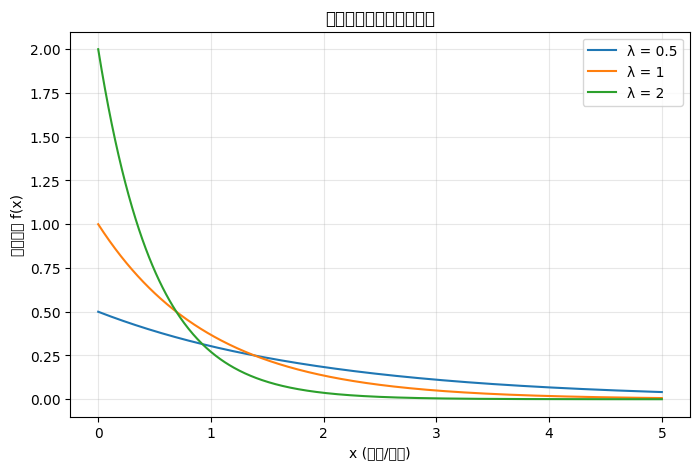

In [3]:
# 定义指数分布的概率密度函数: f(x) = λ * e^(-λ*x), x >= 0
def exp_pdf(x, lam):
    return lam * np.exp(-lam * x)

x = np.linspace(0, 5, 500)  # x 从 0 到 5
lambdas = [0.5, 1, 2]       # 不同的 λ（速率参数）

plt.figure(figsize=(8,5))
for lam in lambdas:
    y = exp_pdf(x, lam)
    plt.plot(x, y, label=f'λ = {lam}')

plt.title('指数分布的概率密度曲线')
plt.xlabel('x (时间/距离)')
plt.ylabel('概率密度 f(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

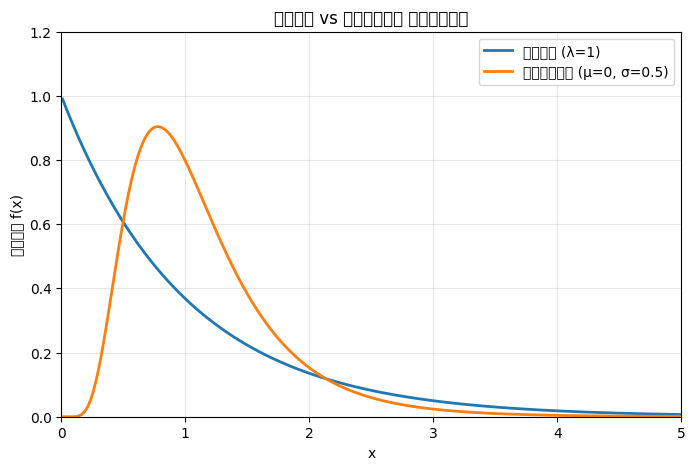

In [4]:
# 设置参数
# 指数分布：速率 lambda = 1 (均值=1)
lam = 1
# 对数正态分布：取对数后的均值为0，标准差为0.5 (偏度适中)
mu, sigma = 0, 0.5

# x 范围 (0 到 5，避开0以避免对数正态在0处无定义)
x = np.linspace(0.01, 5, 500)

# 计算概率密度
exp_pdf = expon.pdf(x, scale=1/lam)      # expon 的 scale = 1/lambda
lognorm_pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))  # s=sigma, scale=e^mu

# 绘图
plt.figure(figsize=(8,5))
plt.plot(x, exp_pdf, label=f'指数分布 (λ={lam})', lw=2)
plt.plot(x, lognorm_pdf, label=f'对数正态分布 (μ={mu}, σ={sigma})', lw=2)
plt.title('指数分布 vs 对数正态分布 概率密度曲线')
plt.xlabel('x')
plt.ylabel('概率密度 f(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1.2)
plt.show()

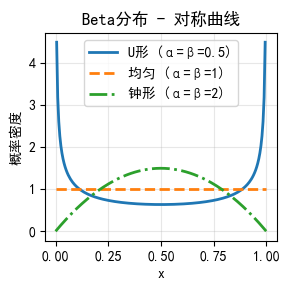

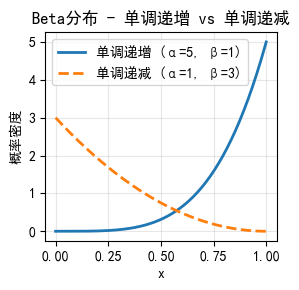

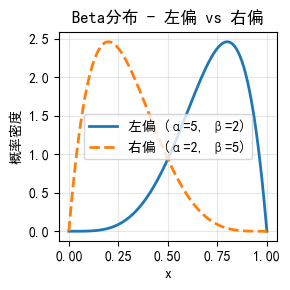

In [14]:
from scipy.stats import beta

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

x = np.linspace(0, 1, 200)

# ========== 图1：对称曲线 ==========
plt.figure(figsize=(3,3))
params_sym = [
    (0.5, 0.5, 'U形 (α=β=0.5)', '-'),          # 实线
    (1, 1, '均匀 (α=β=1)', '--'),               # 虚线
    (2, 2, '钟形 (α=β=2)', '-.')                # 点划线
]
for a, b, label, linestyle in params_sym:
    y = beta.pdf(x, a, b)
    plt.plot(x, y, label=label, linestyle=linestyle, linewidth=2)
plt.title('Beta分布 - 对称曲线')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图2：单调递增 vs 单调递减 ==========
plt.figure(figsize=(3,3))
y_inc = beta.pdf(x, 5, 1)
y_dec = beta.pdf(x, 1, 3)
plt.plot(x, y_inc, label='单调递增 (α=5, β=1)', linestyle='-', linewidth=2)   # 实线
plt.plot(x, y_dec, label='单调递减 (α=1, β=3)', linestyle='--', linewidth=2)  # 虚线
plt.title('Beta分布 - 单调递增 vs 单调递减')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图3：左偏 vs 右偏 ==========
plt.figure(figsize=(3,3))
y_left = beta.pdf(x, 5, 2)
y_right = beta.pdf(x, 2, 5)
plt.plot(x, y_left, label='左偏 (α=5, β=2)', linestyle='-', linewidth=2)      # 实线
plt.plot(x, y_right, label='右偏 (α=2, β=5)', linestyle='--', linewidth=2)     # 虚线
plt.title('Beta分布 - 左偏 vs 右偏')
plt.xlabel('x')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def trunc_norm_pdf(x, mu, sigma, a, b):
    """截断正态分布密度"""
    norm_dist = norm(loc=mu, scale=sigma)
    cdf_a, cdf_b = norm_dist.cdf(a), norm_dist.cdf(b)
    return norm_dist.pdf(x) / (cdf_b - cdf_a) if (x >= a) & (x <= b) else 0

# 参数
d = np.linspace(0, 10, 300)
# 1. 塔吊
pdf_tower = [trunc_norm_pdf(x, 7.0, 1.5, 0, 10) for x in d]
# 2. 深基坑 (Beta缩放)
alpha, beta_param = 1.5, 3.0
pdf_pit = beta.pdf(d/10, alpha, beta_param) / 10
# 3. 高支模（均匀）
pdf_scaffold = np.ones_like(d) / 10
# 4. 车辆（三角）
tri = triang(c=(6-0)/(10-0), loc=0, scale=10)  # c = (mode - loc)/scale
pdf_vehicle = tri.pdf(d)
# 5. 配电箱（指数截断）
lambda_exp = 0.4
exp_dist = expon(scale=1/lambda_exp)
cdf_10 = exp_dist.cdf(10)
pdf_panel = exp_dist.pdf(d) / cdf_10

# 混合概率
p = [0.3, 0.3, 0.2, 0.1, 0.1]
pdf_mix = (p[0]*np.array(pdf_tower) + p[1]*pdf_pit + p[2]*pdf_scaffold +
           p[3]*pdf_vehicle + p[4]*pdf_panel)

# 绘图
plt.figure(figsize=(10,6))
plt.plot(d, pdf_tower, label='塔吊 (截断正态)', lw=2)
plt.plot(d, pdf_pit, label='深基坑 (Beta右偏)', lw=2)
plt.plot(d, pdf_scaffold, label='高支模 (均匀)', lw=2)
plt.plot(d, pdf_vehicle, label='车辆 (三角)', lw=2)
plt.plot(d, pdf_panel, label='配电箱 (指数)', lw=2)
plt.plot(d, pdf_mix, 'k--', label='总体混合分布', lw=3)
plt.xlabel('距离 (m)')
plt.ylabel('概率密度')
plt.title('不同危险源下的人员距离分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()